In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/soybean-seedsclassification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 610M/610M [00:05<00:00, 109MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1):
['Broken soybeans', 'Spotted soybeans', 'Skin-damaged soybeans', 'Immature soybeans', 'Intact soybeans']


In [ ]:
import os

# Use 'path' directly as classes are located here
data_path = path

# List soybean class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Soybean classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Soybean classes found: ['Broken soybeans', 'Spotted soybeans', 'Skin-damaged soybeans', 'Immature soybeans', 'Intact soybeans']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1) ---
Found 5513 images. Displaying 6 sample images:


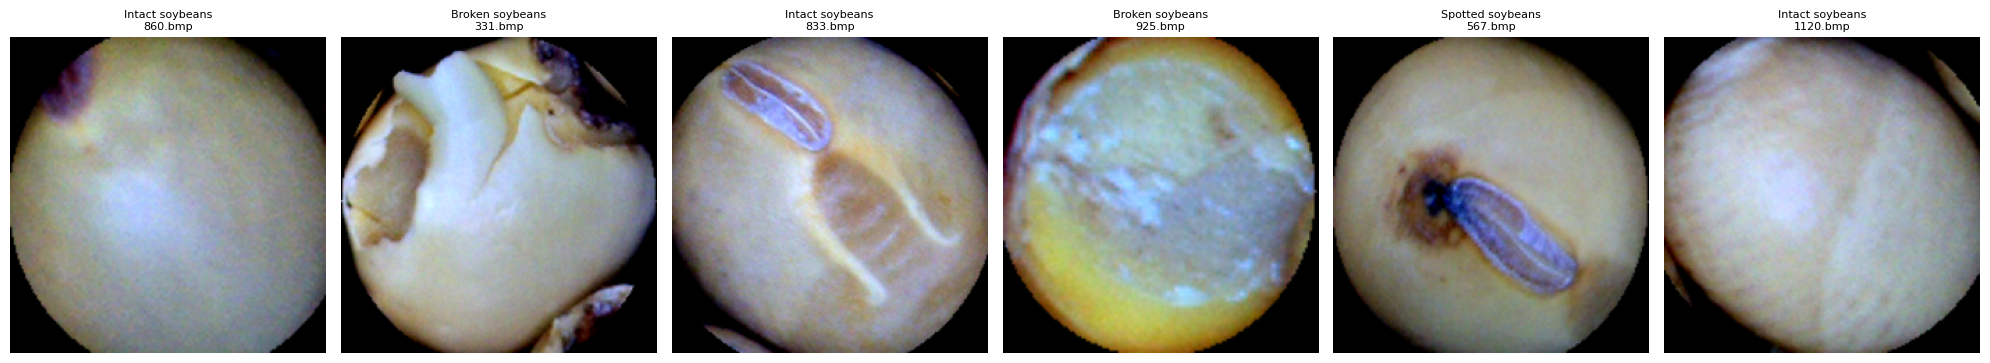

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct path identified in the previous cell
data_path = path
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Define the output folder
output_folder = "soybean_split"

# Split with a ratio of 0.8 for train and 0.2 for val (test)
# seed=1337 ensures reproducibility
splitfolders.ratio(data_path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Dataset successfully split! Check the '{output_folder}' directory.")

Copying files: 5513 files [00:03, 1571.73 files/s]

Dataset successfully split! Check the 'soybean_split' directory.


In [ ]:
# Verify the split results
for split in ['train', 'val']:
    print(f"\n--- {split.upper()} set ---")
    split_path = os.path.join(output_folder, split)
    for class_name in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"{class_name}: {count} images")


--- TRAIN set ---
Broken soybeans: 801 images
Spotted soybeans: 846 images
Skin-damaged soybeans: 901 images
Immature soybeans: 900 images
Intact soybeans: 960 images

--- VAL set ---
Broken soybeans: 201 images
Spotted soybeans: 212 images
Skin-damaged soybeans: 226 images
Immature soybeans: 225 images
Intact soybeans: 241 images


In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
  print(f'Found GPU at: {device_name}')

# Check physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 5

# Data augmentation and loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Building VGG16 Model
with tf.device('/GPU:0'):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base layers

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='categorical_loss',
        metrics=['accuracy']
    )

# Using 'categorical_crossentropy' instead of 'categorical_loss' typo fix
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Starting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Found 4408 images belonging to 5 classes.
Found 1105 images belonging to 5 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training...
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 112s 684ms/step - accuracy: 0.3757 - loss: 1.6817 - val_accuracy: 0.6380 - val_loss: 1.0087
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 68s 496ms/step - accuracy: 0.4519 - loss: 1.2270 - val_accuracy: 0.5991 - val_loss: 0.9291
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 68s 496ms/step - accuracy: 0.4664 - loss: 1.1552 - val_accuracy: 0.6769 - val_loss: 0.8693
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 67s 485ms/step - accuracy: 0.4866 - loss: 1.1247 - val_accuracy: 0.6226 - val_loss: 0.9057
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 68s 496ms/step - accuracy: 0.5098 - loss: 1.0906 - val_accuracy: 0.6579 - val_loss: 0.8212
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 69s 500ms/step - accuracy: 0.5095 - loss: 1.0978 - val_accuracy: 0.6896 - val_loss: 0.8002
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 68s 493ms/step - 

In [ ]:
# Summarize training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Training Summary (after {EPOCHS} epochs):")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Training Summary (after 10 epochs):
Final Training Accuracy: 0.5347
Final Validation Accuracy: 0.7059
Final Training Loss: 1.0541
Final Validation Loss: 0.7650


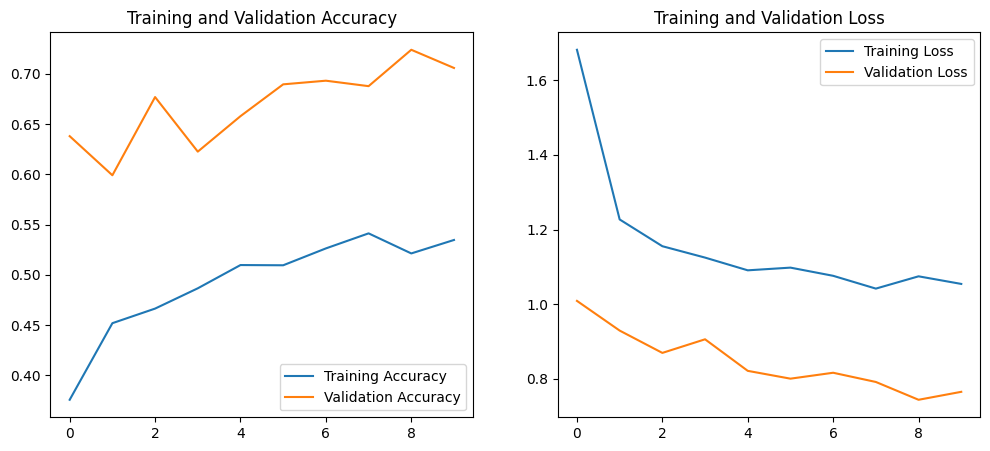

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()